# 07 - Recherche d'hyperparametres (Phase 3 bis)

**Objectif :** trouver de meilleurs hyperparametres qu'un choix par defaut
(learning rate, optimiseur, weight decay, ratio Dice/BCE, batch size) avant
de relancer l'entrainement complet leave-one-trace-out du notebook 06.

**Methodologie :** pour rester rapide sur un GPU 4 Go, chaque test tourne sur
UN SEUL fold (validation sur `FOLD_VALID`, ici Tracee1), avec un nombre
d'epochs reduit (`SEARCH_EPOCHS`). Ce n'est pas un entrainement final -
c'est une recherche comparative. Une fois la meilleure config identifiee,
on la reinjecte dans le notebook 06 pour le vrai entrainement sur les 4 folds.

**Ordre des tests (chaque etape reutilise le meilleur resultat de la
precedente) :**
1. Learning rate (avec Adam, hyperparametres par defaut sinon)
2. Optimiseur (Adam / AdamW / SGD+momentum / RMSprop), au meilleur LR trouve
3. Weight decay (regularisation L2)
4. Ratio Dice/BCE dans la fonction de perte
5. Taille de batch (limite par la memoire GPU)
6. Recommandations supplementaires non testees ici (scheduler de LR, gel de
   l'encodeur) avec justification et code pret a integrer

In [1]:
import sys
sys.path.append('../src/segmentation')

import json
import time
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from dataset import PatchDataset
from model import build_model
from losses import DiceBCELoss

## 1. Configuration

In [2]:
PATCHES_DIR = '../data/processed/patches'
RESULTS_DIR = '../data/results'

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = False           # meme raisonnement que dans le notebook 06 : desactivee

FOLD_VALID = "Tracee1"    # fold utilise pour TOUTE la recherche (rapidite et coherence)
SEARCH_EPOCHS = 10        # court expres : suffisant pour comparer des configs, pas pour entrainer un modele final
BATCH_SIZE = 8
NUM_WORKERS = 0

print(f"Device : {DEVICE}")
print(f"Fold de validation pour la recherche : {FOLD_VALID}")
print(f"Epochs par test : {SEARCH_EPOCHS}")

Device : cuda
Fold de validation pour la recherche : Tracee1
Epochs par test : 10


## 2. Fonctions utilitaires

In [3]:
def build_optimizer(name, params, lr, weight_decay=0.0):
    name = name.lower()
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Optimiseur inconnu : {name}")


def train_quick(lr, optimizer_name="adam", weight_decay=0.0, dice_weight=0.5,
                 bce_weight=0.5, batch_size=BATCH_SIZE, epochs=SEARCH_EPOCHS,
                 fold_valid=FOLD_VALID, verbose=False):
    """Entrainement court sur un seul fold, pour comparer des hyperparametres.
    Retourne un dict avec la config testee, le resultat, et l'historique."""
    train_ds = PatchDataset(PATCHES_DIR, exclude_tracees=[fold_valid])
    valid_ds = PatchDataset(PATCHES_DIR, include_tracees=[fold_valid])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    model = build_model(pretrained=True).to(DEVICE)
    optimizer = build_optimizer(optimizer_name, model.parameters(), lr, weight_decay)
    loss_fn = DiceBCELoss(dice_weight=dice_weight, bce_weight=bce_weight)

    history = {"train_loss": [], "valid_loss": []}
    best_valid_loss = float("inf")
    t0 = time.time()

    try:
        for epoch in range(1, epochs + 1):
            model.train()
            train_loss_total = 0.0
            n_valid_batches = 0
            for images, masks in train_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                optimizer.zero_grad()
                logits = model(images)
                loss = loss_fn(logits, masks)
                if not torch.isfinite(loss):
                    optimizer.zero_grad()
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss_total += loss.item() * images.size(0)
                n_valid_batches += 1
            train_loss = train_loss_total / len(train_ds) if n_valid_batches > 0 else float("nan")

            model.eval()
            valid_loss_total = 0.0
            with torch.no_grad():
                for images, masks in valid_loader:
                    images, masks = images.to(DEVICE), masks.to(DEVICE)
                    logits = model(images)
                    loss = loss_fn(logits, masks)
                    valid_loss_total += loss.item() * images.size(0)
            valid_loss = valid_loss_total / len(valid_ds)

            history["train_loss"].append(train_loss)
            history["valid_loss"].append(valid_loss)
            best_valid_loss = min(best_valid_loss, valid_loss)

            if verbose:
                print(f"    epoch {epoch}/{epochs} | train={train_loss:.4f} | valid={valid_loss:.4f}")

        elapsed = time.time() - t0
        oom = False
    except torch.cuda.OutOfMemoryError:
        elapsed = time.time() - t0
        best_valid_loss = float("inf")
        oom = True
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return {
        "lr": lr, "optimizer": optimizer_name, "weight_decay": weight_decay,
        "dice_weight": dice_weight, "bce_weight": bce_weight, "batch_size": batch_size,
        "best_valid_loss": best_valid_loss,
        "final_valid_loss": history["valid_loss"][-1] if history["valid_loss"] else float("nan"),
        "elapsed_s": elapsed, "oom": oom, "history": history,
    }

## 3. Etape 1 - Recherche du learning rate

On teste plusieurs ordres de grandeur (echelle logarithmique, comme c'est
l'usage pour le LR) avec l'optimiseur Adam par defaut. On garde celui qui
donne la meilleure `best_valid_loss`.

In [4]:
LR_CANDIDATES = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]

resultats_lr = []
for lr in LR_CANDIDATES:
    print(f"Test LR = {lr:.0e}")
    r = train_quick(lr=lr, optimizer_name="adam")
    resultats_lr.append(r)
    tag = " [OOM]" if r["oom"] else ""
    print(f"  -> best_valid_loss = {r['best_valid_loss']:.4f} ({r['elapsed_s']:.0f}s){tag}")

best_lr_result = min(resultats_lr, key=lambda r: r["best_valid_loss"])
best_lr = best_lr_result["lr"]
print(f"\nMeilleur LR trouve : {best_lr:.0e} (best_valid_loss={best_lr_result['best_valid_loss']:.4f})")

Test LR = 1e-05
  -> best_valid_loss = 0.5131 (138s)
Test LR = 3e-05
  -> best_valid_loss = 0.3746 (136s)
Test LR = 1e-04
  -> best_valid_loss = 0.2225 (137s)
Test LR = 3e-04
  -> best_valid_loss = 0.1878 (137s)
Test LR = 1e-03
  -> best_valid_loss = 0.1954 (137s)
Test LR = 3e-03
  -> best_valid_loss = 0.2863 (137s)

Meilleur LR trouve : 3e-04 (best_valid_loss=0.1878)


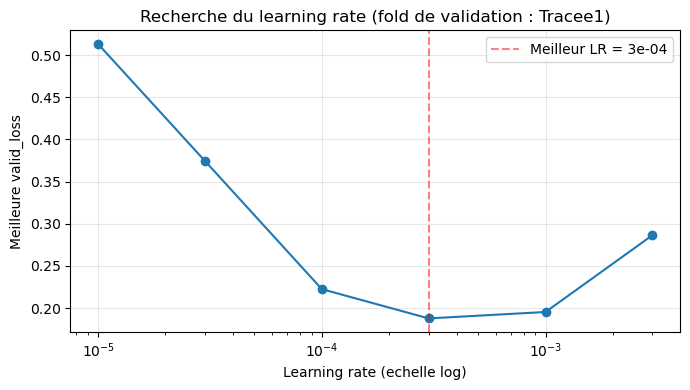

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
lrs = [r["lr"] for r in resultats_lr]
losses = [r["best_valid_loss"] for r in resultats_lr]
ax.plot(lrs, losses, marker="o")
ax.set_xscale("log")
ax.set_xlabel("Learning rate (echelle log)")
ax.set_ylabel("Meilleure valid_loss")
ax.set_title(f"Recherche du learning rate (fold de validation : {FOLD_VALID})")
ax.axvline(best_lr, color="red", linestyle="--", alpha=0.5, label=f"Meilleur LR = {best_lr:.0e}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(Path(RESULTS_DIR) / "recherche_learning_rate.png", dpi=120)
plt.show()

## 4. Etape 2 - Comparaison d'optimiseurs

Au meilleur LR trouve, on compare 4 optimiseurs standards :
- **Adam** : le choix par defaut actuel, adaptatif, generalement un bon point de depart.
- **AdamW** : variante d'Adam avec un decoupling correct du weight decay (souvent legerement meilleur qu'Adam quand on utilise de la regularisation L2).
- **SGD + momentum** : moins adaptatif, converge parfois plus lentement mais peut mieux generaliser sur certains problemes (a voir empiriquement ici).
- **RMSprop** : adaptatif comme Adam, parfois utilise en segmentation.

In [6]:
OPTIMIZERS_A_TESTER = ["adam", "adamw", "sgd", "rmsprop"]

resultats_opt = []
for opt_name in OPTIMIZERS_A_TESTER:
    print(f"Test optimiseur = {opt_name}")
    r = train_quick(lr=best_lr, optimizer_name=opt_name)
    resultats_opt.append(r)
    tag = " [OOM]" if r["oom"] else ""
    print(f"  -> best_valid_loss = {r['best_valid_loss']:.4f} ({r['elapsed_s']:.0f}s){tag}")

best_opt_result = min(resultats_opt, key=lambda r: r["best_valid_loss"])
best_optimizer = best_opt_result["optimizer"]
print(f"\nMeilleur optimiseur trouve : {best_optimizer} (best_valid_loss={best_opt_result['best_valid_loss']:.4f})")

Test optimiseur = adam
  -> best_valid_loss = 0.1886 (137s)
Test optimiseur = adamw
  -> best_valid_loss = 0.1901 (136s)
Test optimiseur = sgd
  -> best_valid_loss = 0.5333 (134s)
Test optimiseur = rmsprop
  -> best_valid_loss = 0.1815 (135s)

Meilleur optimiseur trouve : rmsprop (best_valid_loss=0.1815)


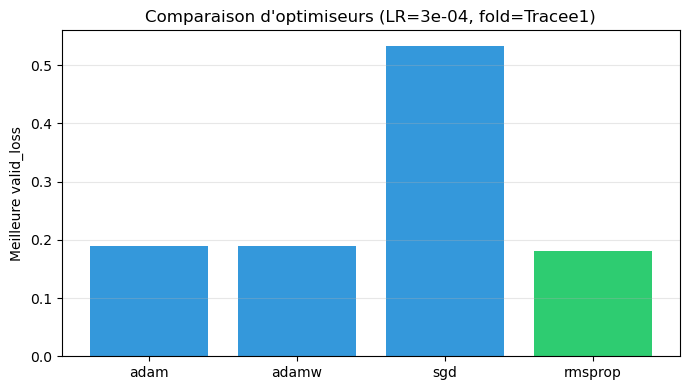

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
noms = [r["optimizer"] for r in resultats_opt]
losses = [r["best_valid_loss"] for r in resultats_opt]
colors = ["#2ecc71" if n == best_optimizer else "#3498db" for n in noms]
ax.bar(noms, losses, color=colors)
ax.set_ylabel("Meilleure valid_loss")
ax.set_title(f"Comparaison d'optimiseurs (LR={best_lr:.0e}, fold={FOLD_VALID})")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(Path(RESULTS_DIR) / "comparaison_optimiseurs.png", dpi=120)
plt.show()

## 5. Etape 3 - Weight decay (regularisation L2)

Un weight decay trop faible peut favoriser le surapprentissage deja observe
dans le notebook 06 ; trop fort peut empecher le modele d'apprendre
(underfitting). On cherche un compromis.

In [8]:
WEIGHT_DECAYS = [0.0, 1e-5, 1e-4, 1e-3]

resultats_wd = []
for wd in WEIGHT_DECAYS:
    print(f"Test weight_decay = {wd:.0e}")
    r = train_quick(lr=best_lr, optimizer_name=best_optimizer, weight_decay=wd)
    resultats_wd.append(r)
    print(f"  -> best_valid_loss = {r['best_valid_loss']:.4f} ({r['elapsed_s']:.0f}s)")

best_wd_result = min(resultats_wd, key=lambda r: r["best_valid_loss"])
best_weight_decay = best_wd_result["weight_decay"]
print(f"\nMeilleur weight_decay trouve : {best_weight_decay:.0e} (best_valid_loss={best_wd_result['best_valid_loss']:.4f})")

Test weight_decay = 0e+00
  -> best_valid_loss = 0.1812 (136s)
Test weight_decay = 1e-05
  -> best_valid_loss = 0.1959 (136s)
Test weight_decay = 1e-04
  -> best_valid_loss = 0.1904 (136s)
Test weight_decay = 1e-03
  -> best_valid_loss = 0.2208 (137s)

Meilleur weight_decay trouve : 0e+00 (best_valid_loss=0.1812)


## 6. Etape 4 - Ratio Dice / BCE dans la fonction de perte

`DiceBCELoss` combine les deux termes avec des poids `dice_weight` +
`bce_weight` (actuellement 0.5/0.5). On teste si un rapport different
ameliore la segmentation (le Dice est plus sensible au chevauchement global,
la BCE penalise chaque pixel - utile vu le desequilibre piece/fond).

In [9]:
RATIOS_DICE_BCE = [(0.3, 0.7), (0.5, 0.5), (0.7, 0.3)]

resultats_ratio = []
for dw, bw in RATIOS_DICE_BCE:
    print(f"Test dice_weight={dw}, bce_weight={bw}")
    r = train_quick(lr=best_lr, optimizer_name=best_optimizer, weight_decay=best_weight_decay,
                     dice_weight=dw, bce_weight=bw)
    resultats_ratio.append(r)
    print(f"  -> best_valid_loss = {r['best_valid_loss']:.4f} ({r['elapsed_s']:.0f}s)")

best_ratio_result = min(resultats_ratio, key=lambda r: r["best_valid_loss"])
best_dice_weight = best_ratio_result["dice_weight"]
best_bce_weight = best_ratio_result["bce_weight"]
print(f"\nMeilleur ratio trouve : dice={best_dice_weight}, bce={best_bce_weight} "
      f"(best_valid_loss={best_ratio_result['best_valid_loss']:.4f})")

Test dice_weight=0.3, bce_weight=0.7
  -> best_valid_loss = 0.1924 (135s)
Test dice_weight=0.5, bce_weight=0.5
  -> best_valid_loss = 0.1998 (134s)
Test dice_weight=0.7, bce_weight=0.3
  -> best_valid_loss = 0.1911 (135s)

Meilleur ratio trouve : dice=0.7, bce=0.3 (best_valid_loss=0.1911)


## 7. Etape 5 - Taille de batch

Limite avant tout par la memoire GPU (4 Go). On teste plusieurs tailles avec
la meilleure config trouvee jusqu'ici ; si une taille declenche un
"out of memory", le test est marque OOM et ignore automatiquement.

In [10]:
BATCH_SIZES = [4, 8, 16]

resultats_bs = []
for bs in BATCH_SIZES:
    print(f"Test batch_size = {bs}")
    r = train_quick(lr=best_lr, optimizer_name=best_optimizer, weight_decay=best_weight_decay,
                     dice_weight=best_dice_weight, bce_weight=best_bce_weight, batch_size=bs)
    resultats_bs.append(r)
    if r["oom"]:
        print(f"  -> OUT OF MEMORY avec batch_size={bs}, ignore")
    else:
        print(f"  -> best_valid_loss = {r['best_valid_loss']:.4f} ({r['elapsed_s']:.0f}s)")

resultats_bs_valides = [r for r in resultats_bs if not r["oom"]]
best_bs_result = min(resultats_bs_valides, key=lambda r: r["best_valid_loss"])
best_batch_size = best_bs_result["batch_size"]
print(f"\nMeilleur batch_size trouve : {best_batch_size} (best_valid_loss={best_bs_result['best_valid_loss']:.4f})")

Test batch_size = 4
  -> best_valid_loss = 0.1950 (150s)
Test batch_size = 8
  -> best_valid_loss = 0.1958 (138s)
Test batch_size = 16
  -> best_valid_loss = 0.2090 (120s)

Meilleur batch_size trouve : 4 (best_valid_loss=0.1950)


## 8. Recommandations supplementaires (non testees ici)

Ces deux reglages sont connus pour ameliorer l'entrainement dans des cas
similaires (encodeur pre-entraine + decodeur aleatoire, dataset limite),
mais necessitent un test sur plusieurs epochs plus long pour etre values
correctement - je ne les ai pas integres a la recherche automatique
ci-dessus pour rester dans un temps raisonnable. Voici comment les integrer
au notebook 06 si tu veux les essayer :

**A. Scheduler de learning rate (`ReduceLROnPlateau`)** - reduit
automatiquement le LR quand `valid_loss` stagne, ce qui peut aider a
affiner la convergence dans les dernieres epochs (complementaire de
l'early stopping, pas redondant) :
```python
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)
# apres le calcul de valid_loss, a chaque epoch :
scheduler.step(valid_loss)
```

**B. Gel temporaire de l'encodeur pre-entraine** - entrainer d'abord
uniquement le decodeur (aleatoire) pendant quelques epochs pendant que
l'encodeur reste fige, avant de tout de-geler. Ca laisse au decodeur le
temps de se stabiliser sans perturber les poids ImageNet deja bons :
```python
for param in model.encoder.parameters():
    param.requires_grad = False
# ... entrainer N epochs, puis :
for param in model.encoder.parameters():
    param.requires_grad = True
# reduire le LR au moment du degel, ex. LR / 10
```
(le nom exact de l'attribut `model.encoder` depend de `segmentation-models-pytorch` - a verifier avec `model.encoder` ou `dir(model)` si erreur)

## 9. Resume final et sauvegarde de la meilleure configuration

In [11]:
meilleure_config = {
    "learning_rate": best_lr,
    "optimizer": best_optimizer,
    "weight_decay": best_weight_decay,
    "dice_weight": best_dice_weight,
    "bce_weight": best_bce_weight,
    "batch_size": best_batch_size,
    "fold_utilise_pour_la_recherche": FOLD_VALID,
    "search_epochs": SEARCH_EPOCHS,
    "best_valid_loss_trouvee": min(
        best_lr_result["best_valid_loss"], best_opt_result["best_valid_loss"],
        best_wd_result["best_valid_loss"], best_ratio_result["best_valid_loss"],
        best_bs_result["best_valid_loss"],
    ),
}

print("="*70)
print("MEILLEURE CONFIGURATION TROUVEE")
print("="*70)
for k, v in meilleure_config.items():
    print(f"  {k:35s} : {v}")

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)
with open(Path(RESULTS_DIR) / "meilleurs_hyperparametres.json", "w") as f:
    json.dump(meilleure_config, f, indent=2)

print(f"\nSauvegarde dans {RESULTS_DIR}/meilleurs_hyperparametres.json")
print("\nProchaine etape : reporter ces valeurs dans la cellule de configuration")
print("du notebook 06 (LEARNING_RATE, optimiseur dans train_one_fold, "
      "DiceBCELoss(dice_weight=..., bce_weight=...), BATCH_SIZE), puis "
      "relancer l'entrainement complet leave-one-trace-out.")

MEILLEURE CONFIGURATION TROUVEE
  learning_rate                       : 0.0003
  optimizer                           : rmsprop
  weight_decay                        : 0.0
  dice_weight                         : 0.7
  bce_weight                          : 0.3
  batch_size                          : 4
  fold_utilise_pour_la_recherche      : Tracee1
  search_epochs                       : 10
  best_valid_loss_trouvee             : 0.18124456363064903

Sauvegarde dans ../data/results/meilleurs_hyperparametres.json

Prochaine etape : reporter ces valeurs dans la cellule de configuration
du notebook 06 (LEARNING_RATE, optimiseur dans train_one_fold, DiceBCELoss(dice_weight=..., bce_weight=...), BATCH_SIZE), puis relancer l'entrainement complet leave-one-trace-out.
